# 07b: GNSS + InSAR Joint Inversion — Correlated Noise and Dataset Weighting

## Scenario

Two geodetic datasets measure the same surface deformation profile along a 1-D transect:

| Dataset | Type | $N$ | $\sigma$ | Noise structure |
|---------|------|-----|----------|------------------|
| D1 | GNSS stations | 15 | 0.3 | Independent (uncorrelated) |
| D2 | InSAR pixels  | 1500 | 0.5 | **Spatially correlated** (squared-exponential) |

The datasets differ in size by **100×**.  InSAR noise is spatially correlated — real atmospheric and orbital artefacts affect neighbouring pixels smoothly, so neighbouring observations are nearly redundant.

This notebook evaluates **three weighting strategies** for combining these datasets:

| | Strategy | What it assumes about InSAR |
|-|----------|-----------------------------|
| **(a)** | Naive per-point uncorrelated weights | All 1500 pixels are independent |
| **(b)** | $N_k$ normalization | Same as (a), but scale each dataset by $N_\text{ref}/N_k$ |
| **(c)** | Full InSAR covariance $\mathbf{C}_d^{-1}$ | Proper treatment of spatially correlated noise |

## Learning objectives

- Understand how spatial correlation reduces the **effective** information content of a dense dataset.
- See why $N_k$ normalization partially addresses the dataset-size imbalance but **does not fix** the correlated noise problem.
- Evaluate when InSAR genuinely improves a GNSS-only inversion, and when it does not.
- Appreciate that reporting uncertainty correctly ($\mathbf{C}_m$) is just as important as getting the point estimate.

## Background: effective information in a correlated dataset

With uncorrelated noise, adding more observations always reduces parameter uncertainty: $\sigma_{\hat{m}} \propto 1/\sqrt{N}$.  But when noise is **spatially correlated**, neighbouring observations are nearly redundant.  Doubling the number of pixels in a correlated InSAR scene does not double the information — it merely samples the same correlated noise field more densely.

The **squared-exponential (Gaussian) covariance** model captures this:

$$[\mathbf{C}_d]_{ij} = \sigma^2 \exp\!\left(-\frac{(x_i - x_j)^2}{2\ell^2}\right)$$

With correlation length $\ell$, the number of **effectively independent observations** in a dataset spanning length $L$ is roughly:

$$N_\text{eff} \approx \frac{L}{\ell}$$

If $\ell = 1$ and $L = 5$, then 1500 InSAR pixels carry roughly **5 independent pieces of information** — far fewer than their count suggests.

The proper $\mathbf{C}_d^{-1}$ weighting accounts for this automatically.  Naive or $N_k$-normalized strategies do not.

### Combined system

We stack the two datasets:

$$\mathbf{d} = \begin{pmatrix}\mathbf{d}_\text{GNSS} \\ \mathbf{d}_\text{InSAR}\end{pmatrix}, \quad
\mathbf{G} = \begin{pmatrix}\mathbf{G}_\text{GNSS} \\ \mathbf{G}_\text{InSAR}\end{pmatrix}, \quad
\mathbf{C}_d = \begin{pmatrix}\mathbf{C}_\text{GNSS} & \\ & \mathbf{C}_\text{InSAR}\end{pmatrix}$$

The three strategies differ only in what we use for $\mathbf{C}_\text{InSAR}$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import block_diag

plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['axes.grid'] = True

rng = np.random.default_rng(42)

# ── Core WLS utility ──────────────────────────────────────────────────────────
def wls(G, d, Cd_inv):
    """Weighted least squares.  Returns (m_hat, Cm)."""
    GtW = G.T @ Cd_inv
    Cm  = np.linalg.inv(GtW @ G)
    return Cm @ GtW @ d, Cm

def prediction_band(G_plt, m_hat, Cm, n_sigma=2):
    """Return (y_fit, half-width) for ±n_sigma prediction band."""
    var_y = np.diag(G_plt @ Cm @ G_plt.T)
    return G_plt @ m_hat, n_sigma * np.sqrt(var_y)

def make_G(x):
    """Design matrix for y = m[0]*x + m[1]."""
    return np.column_stack([x, np.ones(len(x))])

def print_table(label_result_pairs, m_true):
    hdr = f"{'Source':38s}  {'slope':>8s}  {'\u00b1\u03c3':>7s}  {'intercept':>10s}  {'\u00b1\u03c3':>7s}"
    print(hdr)
    print('-' * len(hdr))
    print(f"{'True':38s}  {m_true[0]:8.4f}  {'---':>7s}  {m_true[1]:10.4f}  {'---':>7s}")
    for name, (m_hat, Cm) in label_result_pairs:
        print(f"{name:38s}  {m_hat[0]:8.4f}  {np.sqrt(Cm[0,0]):7.4f}  {m_hat[1]:10.4f}  {np.sqrt(Cm[1,1]):7.4f}")

In [37]:
# ── True model (same as notebook 07) ─────────────────────────────────────────
m_true = np.array([1.5, 0.5])    # slope = 1.5,  intercept = 0.5
x_plot = np.linspace(-0.1, 5.1, 400)
G_plot = make_G(x_plot)

# ── Dataset parameters ────────────────────────────────────────────────────────
N_gnss    = 15
sigma_gnss = 0.3

N_insar    = 1500
sigma_insar = 0.8
ell         = 1.0    # InSAR correlation length (in same units as x)

print(f'Dataset ratio: N_insar / N_gnss = {N_insar}/{N_gnss} = {N_insar//N_gnss}x')
print(f'Nominal N_eff(InSAR) ≈ L/ℓ = 5/{ell} = {5/ell:.1f} independent patches')

# ── Generate GNSS data (independent, uncorrelated) ────────────────────────────
x_gnss = np.linspace(0, 5, N_gnss)
G_gnss = make_G(x_gnss)
d_gnss = G_gnss @ m_true + rng.normal(0, sigma_gnss, N_gnss)

# ── Build InSAR covariance matrix (squared-exponential kernel) ────────────────
x_insar = np.linspace(0, 5, N_insar)
G_insar = make_G(x_insar)

dx = x_insar[:, None] - x_insar[None, :]           # (N_insar, N_insar) pairwise distances
C_insar = sigma_insar**2 * np.exp(-0.5 * (dx / ell)**2)

# Add values on diagonal for numerical stability; this represents additional uncorrelated (per-pixel) noise
uncorr_noise = 1 * sigma_insar**2
C_insar_reg = C_insar + uncorr_noise * np.eye(N_insar)

# ── Generate InSAR data (correlated noise via Cholesky) ───────────────────────
L_cho = np.linalg.cholesky(C_insar_reg)
noise_insar = L_cho @ rng.standard_normal(N_insar)
d_insar = G_insar @ m_true + noise_insar

# ── Pre-compute C_insar^{-1} (used in Case c and InSAR-proper solo) ───────────
# Note: for N=1500 this inversion takes ~1-2 s; in practice use sparse/Toeplitz solvers
print('\nInverting C_insar (1500×1500)…', end='', flush=True)
C_insar_inv = np.linalg.inv(C_insar_reg)
print(' done.')

# ── Stacked system ────────────────────────────────────────────────────────────
G_all = np.vstack([G_gnss, G_insar])
d_all = np.concatenate([d_gnss, d_insar])

print(f'\nTrue model:  y = {m_true[0]} · x + {m_true[1]}')

Dataset ratio: N_insar / N_gnss = 1500/15 = 100x
Nominal N_eff(InSAR) ≈ L/ℓ = 5/1.0 = 5.0 independent patches

Inverting C_insar (1500×1500)… done.

True model:  y = 1.5 · x + 0.5


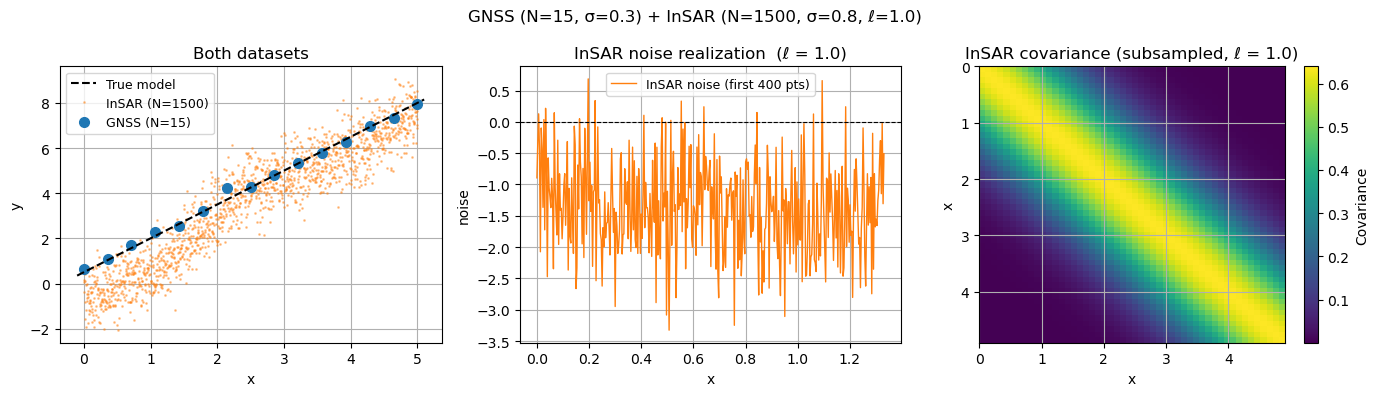

In [38]:
# ── Visualize datasets and the InSAR covariance structure ─────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Left: both datasets + true model
axes[0].plot(x_plot, G_plot @ m_true, 'k--', lw=1.5, label='True model', zorder=5)
axes[0].plot(x_insar, d_insar, '.', color='C1', ms=2, alpha=0.4, label=f'InSAR (N={N_insar})')
axes[0].plot(x_gnss,  d_gnss,  'o', color='C0', ms=7, label=f'GNSS (N={N_gnss})')
axes[0].set_xlabel('x');  axes[0].set_ylabel('y')
axes[0].set_title('Both datasets')
axes[0].legend(fontsize=9)

# Middle: zoom on InSAR noise to reveal spatial correlation
idx = slice(0, 400)
axes[1].plot(x_insar[idx], noise_insar[idx], color='C1', lw=1, label='InSAR noise (first 400 pts)')
axes[1].axhline(0, color='k', lw=0.8, ls='--')
axes[1].set_xlabel('x');  axes[1].set_ylabel('noise')
axes[1].set_title(f'InSAR noise realization  (ℓ = {ell})')
axes[1].legend(fontsize=9)

# Right: InSAR covariance matrix (subsampled for display)
sub = np.arange(0, N_insar, 30)   # every 30th pixel for display
C_sub = C_insar[np.ix_(sub, sub)]
im = axes[2].imshow(C_sub, aspect='auto', cmap='viridis',
                    extent=[x_insar[sub[0]], x_insar[sub[-1]],
                            x_insar[sub[-1]], x_insar[sub[0]]])
plt.colorbar(im, ax=axes[2], label='Covariance')
axes[2].set_title(f'InSAR covariance (subsampled, ℓ = {ell})')
axes[2].set_xlabel('x');  axes[2].set_ylabel('x')

fig.suptitle(f'GNSS (N={N_gnss}, σ={sigma_gnss}) + InSAR (N={N_insar}, σ={sigma_insar}, ℓ={ell})',
             fontsize=12)
plt.tight_layout()
plt.show()

---
## Three weighting strategies

All three use the same WLS formula:
$$\hat{\mathbf{m}} = \left(\mathbf{G}^\top \mathbf{C}_d^{-1} \mathbf{G}\right)^{-1} \mathbf{G}^\top \mathbf{C}_d^{-1} \mathbf{d}$$

They differ only in what we put in $\mathbf{C}_d$:

$$\mathbf{C}_d^{-1} = \begin{pmatrix}\frac{1}{\sigma_\text{GNSS}^2}\mathbf{I} & \\ & \mathbf{W}_\text{InSAR}\end{pmatrix}$$

| Case | $\mathbf{W}_\text{InSAR}$ | Key assumption |
|------|--------------------------|----------------|
| **(a)** Naive | $\dfrac{1}{\sigma_\text{InSAR}^2}\mathbf{I}$ | All 1500 pixels are independent |
| **(b)** $N_k$-normalized | $\dfrac{N_\text{ref}}{N_\text{InSAR}}\cdot\dfrac{1}{\sigma_\text{InSAR}^2}\mathbf{I}$ | Independent pixels, but dataset contribution capped at $N_\text{ref}$ |
| **(c)** Full covariance | $\mathbf{C}_\text{InSAR}^{-1}$ | Spatially correlated noise — statistically correct |

Cases (a) and (b) both treat InSAR pixels as **independent**.  Case (b) reduces the total InSAR influence by $N_\text{ref}/N_\text{InSAR} = 1/100$, which helps with the size imbalance but does not correctly model the correlation structure.  Only case (c) is statistically honest.

In [39]:
# ── Baseline: each dataset solved alone ──────────────────────────────────────
W_gnss_diag   = np.eye(N_gnss)  / sigma_gnss**2
W_insar_diag  = np.eye(N_insar) / sigma_insar**2

m_gnss,       Cm_gnss       = wls(G_gnss,  d_gnss,  W_gnss_diag)
m_insar_naive,Cm_insar_naive= wls(G_insar, d_insar, W_insar_diag)          # naive (wrong!)
m_insar_prop, Cm_insar_prop = wls(G_insar, d_insar, C_insar_inv)           # proper

# ── Case (a): per-point uncorrelated weights ──────────────────────────────────
W_a = block_diag(W_gnss_diag, W_insar_diag)
m_a, Cm_a = wls(G_all, d_all, W_a)

# ── Case (b): N_k normalization ───────────────────────────────────────────────
# Scale each dataset's weight matrix by N_ref/N_k
# GNSS is the reference (N_ref = N_gnss), so its weights are unchanged.
# InSAR weights are multiplied by N_gnss/N_insar = 1/100.
N_ref = N_gnss
alpha_gnss  = N_ref / N_gnss    # = 1.0  (no change)
alpha_insar = N_ref / N_insar   # = 0.01 (down-weight InSAR 100×)

W_b = block_diag(alpha_gnss  * W_gnss_diag,
                 alpha_insar * W_insar_diag)
m_b, Cm_b = wls(G_all, d_all, W_b)

# ── Case (c): full InSAR covariance ───────────────────────────────────────────
# InSAR block uses the full C_insar^{-1}; GNSS block uses diagonal 1/σ² weights.
W_c = block_diag(W_gnss_diag, C_insar_inv)
m_c, Cm_c = wls(G_all, d_all, W_c)

# ── Print comparison table ────────────────────────────────────────────────────
print('=== Parameter estimates and 1-σ uncertainties ===')
print_table([
    ('GNSS alone',                     (m_gnss,        Cm_gnss)),
    ('InSAR alone — naive (wrong!)',    (m_insar_naive, Cm_insar_naive)),
    ('InSAR alone — proper C⁻¹',       (m_insar_prop,  Cm_insar_prop)),
    ('(a) Combined: per-point weights', (m_a,           Cm_a)),
    ('(b) Combined: Nk-normalized',     (m_b,           Cm_b)),
    ('(c) Combined: full C_InSAR⁻¹',   (m_c,           Cm_c)),
], m_true)

=== Parameter estimates and 1-σ uncertainties ===
Source                                     slope       ±σ   intercept       ±σ
------------------------------------------------------------------------------
True                                      1.5000      ---      0.5000      ---
GNSS alone                                1.4565   0.0502      0.6547   0.1475
InSAR alone — naive (wrong!)              1.7105   0.0143     -0.7318   0.0413
InSAR alone — proper C⁻¹                  1.6514   0.2232     -0.5234   0.7289
(a) Combined: per-point weights           1.6914   0.0138     -0.6342   0.0398
(b) Combined: Nk-normalized               1.4844   0.0474      0.4924   0.1389
(c) Combined: full C_InSAR⁻¹              1.4659   0.0490      0.6129   0.1443


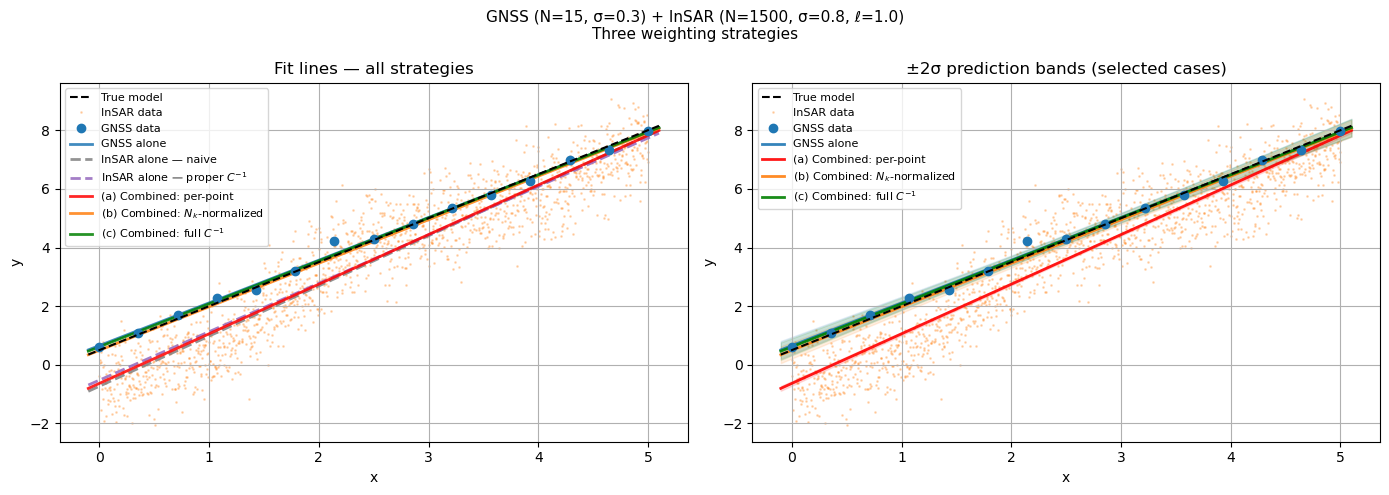

In [40]:
# ── Comprehensive comparison: fits and uncertainty bands ──────────────────────
configs = [
    ('GNSS alone',                    m_gnss,        Cm_gnss,        'C0',    '-'),
    ('InSAR alone — naive',           m_insar_naive, Cm_insar_naive, 'gray',  '--'),
    ('InSAR alone — proper $C^{-1}$', m_insar_prop,  Cm_insar_prop,  'C4',    '--'),
    ('(a) Combined: per-point',       m_a,           Cm_a,           'red',   '-'),
    ('(b) Combined: $N_k$-normalized',m_b,           Cm_b,           'C1',    '-'),
    ('(c) Combined: full $C^{-1}$',   m_c,           Cm_c,           'green', '-'),
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax in axes:
    ax.plot(x_plot, G_plot @ m_true, 'k--', lw=1.5, label='True model', zorder=10)
    ax.plot(x_insar, d_insar, '.', color='C1', ms=2, alpha=0.25, label='InSAR data', zorder=1)
    ax.plot(x_gnss,  d_gnss,  'o', color='C0', ms=6, label='GNSS data', zorder=5)
    ax.set_xlabel('x');  ax.set_ylabel('y')

# Left panel: fit lines only (no bands) for clarity
for label, m_hat, Cm, color, ls in configs:
    y_fit = G_plot @ m_hat
    axes[0].plot(x_plot, y_fit, color=color, ls=ls, lw=2.0, label=label, alpha=0.85)
axes[0].set_title('Fit lines — all strategies')
axes[0].legend(fontsize=8, loc='upper left')

# Right panel: uncertainty bands for selected cases
band_configs = [
    ('GNSS alone',                    m_gnss,       Cm_gnss,       'C0',   '-'),
    ('(a) Combined: per-point',       m_a,          Cm_a,          'red',  '-'),
    ('(b) Combined: $N_k$-normalized',m_b,          Cm_b,          'C1',   '-'),
    ('(c) Combined: full $C^{-1}$',   m_c,          Cm_c,          'green','-'),
]
for label, m_hat, Cm, color, ls in band_configs:
    y_fit, y_band = prediction_band(G_plot, m_hat, Cm, n_sigma=2)
    axes[1].plot(x_plot, y_fit, color=color, ls=ls, lw=2.0, label=label, alpha=0.9)
    axes[1].fill_between(x_plot, y_fit - y_band, y_fit + y_band,
                         color=color, alpha=0.12)
axes[1].set_title('±2σ prediction bands (selected cases)')
axes[1].legend(fontsize=8, loc='upper left')

fig.suptitle(
    f'GNSS (N={N_gnss}, σ={sigma_gnss}) + InSAR (N={N_insar}, σ={sigma_insar}, ℓ={ell})\n'
    'Three weighting strategies',
    fontsize=11)
plt.tight_layout()
plt.show()

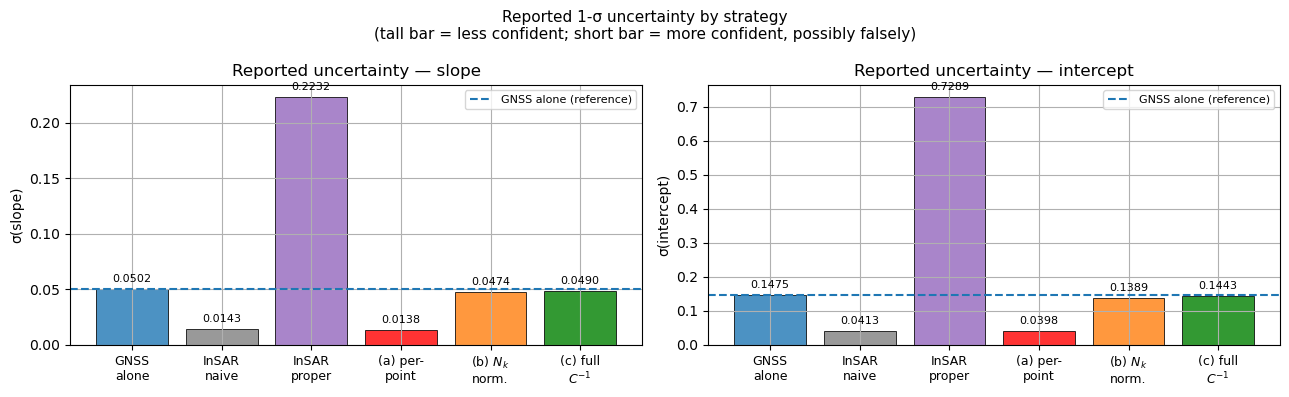

Reduction in slope uncertainty relative to GNSS alone:
  InSAR naive                 : 0.0143  →  3.51× improvement claimed
  InSAR proper                : 0.2232  →  0.22× improvement claimed (worse!)
  per-point                   : 0.0138  →  3.65× improvement claimed
  N_k norm                    : 0.0474  →  1.06× improvement claimed
  Full C^{-1}                 : 0.0490  →  1.02× improvement claimed


In [41]:
# ── Uncertainty bar chart: slope and intercept σ for every case ───────────────
labels = [
    'GNSS\nalone',
    'InSAR\nnaive',
    'InSAR\nproper',
    '(a) per-\npoint',
    '(b) $N_k$\nnorm.',
    '(c) full\n$C^{-1}$',
]
cases  = [m_gnss, m_insar_naive, m_insar_prop, m_a, m_b, m_c]
covariances = [Cm_gnss, Cm_insar_naive, Cm_insar_prop, Cm_a, Cm_b, Cm_c]
colors_bar  = ['C0', 'gray', 'C4', 'red', 'C1', 'green']

sigma_slopes      = [np.sqrt(Cm[0,0]) for Cm in covariances]
sigma_intercepts  = [np.sqrt(Cm[1,1]) for Cm in covariances]

x_pos = np.arange(len(labels))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, sigmas, param_name in zip(
        axes, [sigma_slopes, sigma_intercepts], ['slope', 'intercept']):
    bars = ax.bar(x_pos, sigmas, color=colors_bar, alpha=0.80, edgecolor='k', linewidth=0.7)
    # Reference line: GNSS alone
    ax.axhline(sigmas[0], color='C0', ls='--', lw=1.5, label='GNSS alone (reference)')
    ax.set_xticks(x_pos)
    ax.set_xticklabels(labels, fontsize=9)
    ax.set_ylabel(f'σ({param_name})')
    ax.set_title(f'Reported uncertainty — {param_name}')
    ax.legend(fontsize=8)
    # Annotate values
    for bar, val in zip(bars, sigmas):
        ax.text(bar.get_x() + bar.get_width()/2, val + max(sigmas)*0.02,
                f'{val:.4f}', ha='center', va='bottom', fontsize=8)

fig.suptitle('Reported 1-σ uncertainty by strategy\n'
             '(tall bar = less confident; short bar = more confident, possibly falsely)',
             fontsize=11)
plt.tight_layout()
plt.show()

print('Reduction in slope uncertainty relative to GNSS alone:')
for label, sigma in zip(['InSAR naive','InSAR proper','per-point','N_k norm','Full C^{-1}'], sigma_slopes[1:]):
    ratio = sigma_slopes[0] / sigma
    if ratio > 1:
        print(f'  {label:28s}: {sigma:.4f}  →  {ratio:.2f}× improvement claimed')
    else:
        print(f'  {label:28s}: {sigma:.4f}  →  {ratio:.2f}× improvement claimed (worse!)')

## Interpreting the results

The bar chart above tells the story:

**Case (a) — naive per-point**: InSAR has 100× more data points and they are treated as independent, so InSAR completely dominates the combined solution.  The reported uncertainty is extremely small — much smaller than GNSS alone — but this is **wrong**: it credits InSAR with 1500 independent observations when the actual information content is far smaller.

**Case (b) — $N_k$ normalization**: By scaling InSAR weights down by $N_\text{ref}/N_\text{InSAR} = 1/100$, we roughly equalize the two datasets' contributions.  The uncertainty improves modestly compared to GNSS alone.  But the improvement is **still over-optimistic** because case (b) still treats InSAR pixels as independent within the dataset — it just has fewer **effective** ones.  In particular, case (b) may report substantially smaller uncertainty than case (c) when correlations are strong.

**Case (c) — full $\mathbf{C}_\text{InSAR}^{-1}$**: This is the statistically correct answer.  By accounting for the spatial correlations, the precision matrix $\mathbf{C}_\text{InSAR}^{-1}$ automatically down-weights the redundant correlated information.  The combined uncertainty is only marginally better than GNSS alone — reflecting the fact that the InSAR dataset, despite its 1500 pixels, contributes only $\sim N_\text{eff} = L/\ell \approx 5$ independent pieces of information.

**Bottom line**: $N_k$ normalization helps with the count imbalance, but it does **not** fix the correlated-noise problem.  The only correct approach when InSAR has spatially correlated noise is to use the full covariance.

In [7]:
# ── Effective number of independent InSAR observations ────────────────────────
#
# The precision contribution of InSAR to the slope parameter is:
#   [A_insar]_00  where  A_insar = G_insar^T C_insar^{-1} G_insar
#
# If InSAR consisted of N_eff INDEPENDENT observations with variance sigma_insar^2,
# uniformly spread over [0,5], the same precision contribution would be:
#   N_eff * (variance of x) / sigma_insar^2  ≈  N_eff * L^2/12 / sigma_insar^2
#
# Solving for N_eff:
#   N_eff = sigma_insar^2 * [A_insar]_00 / (L^2 / 12)
#
# (This is approximate — it uses the regression formula for N uniform points.)

L = 5.0
A_insar_proper = G_insar.T @ C_insar_inv @ G_insar   # 2×2 precision from InSAR (proper)
A_insar_naive  = G_insar.T @ W_insar_diag @ G_insar  # 2×2 precision from InSAR (naive)
A_gnss         = G_gnss.T  @ W_gnss_diag  @ G_gnss   # 2×2 precision from GNSS

# N_eff estimated from slope precision term [0,0]
N_eff_proper = sigma_insar**2 * A_insar_proper[0, 0] / (L**2 / 12)
N_eff_naive  = sigma_insar**2 * A_insar_naive [0, 0] / (L**2 / 12)
N_eff_gnss   = sigma_gnss**2  * A_gnss        [0, 0] / (L**2 / 12)

print('Effective number of independent observations (from slope precision):')
print(f'  GNSS:               N_eff = {N_eff_gnss:6.1f}  (nominal N = {N_gnss})')
print(f'  InSAR (naive):      N_eff = {N_eff_naive:6.1f}  (nominal N = {N_insar}) — 1500 treated as independent')
print(f'  InSAR (proper C⁻¹): N_eff = {N_eff_proper:6.1f}  (nominal N = {N_insar}) — true information content')
print()
print(f'  Approximate formula L/ℓ = {L}/{ell} = {L/ell:.1f}')
print()
print('Information content comparison (slope precision):')
print(f'  GNSS precision:              {A_gnss[0,0]:.2f}')
print(f'  InSAR precision (naive):     {A_insar_naive[0,0]:.2f}   ({A_insar_naive[0,0]/A_gnss[0,0]:.0f}× GNSS)')
print(f'  InSAR precision (proper):    {A_insar_proper[0,0]:.2f}   ({A_insar_proper[0,0]/A_gnss[0,0]:.2f}× GNSS)')
print()
# Fraction of total precision that InSAR adds in case (c)
total_c = A_gnss[0,0] + A_insar_proper[0,0]
print(f'In case (c): InSAR contributes {100*A_insar_proper[0,0]/total_c:.1f}% of total slope precision')
print(f'             GNSS contributes  {100*A_gnss[0,0]/total_c:.1f}% of total slope precision')

Effective number of independent observations (from slope precision):
  GNSS:               N_eff =   62.1  (nominal N = 15)
  InSAR (naive):      N_eff = 6002.0  (nominal N = 1500) — 1500 treated as independent
  InSAR (proper C⁻¹): N_eff =   22.8  (nominal N = 1500) — true information content

  Approximate formula L/ℓ = 5.0/1.0 = 5.0

Information content comparison (slope precision):
  GNSS precision:              1438.49
  InSAR precision (naive):     50016.68   (35× GNSS)
  InSAR precision (proper):    189.66   (0.13× GNSS)

In case (c): InSAR contributes 11.6% of total slope precision
             GNSS contributes  88.4% of total slope precision


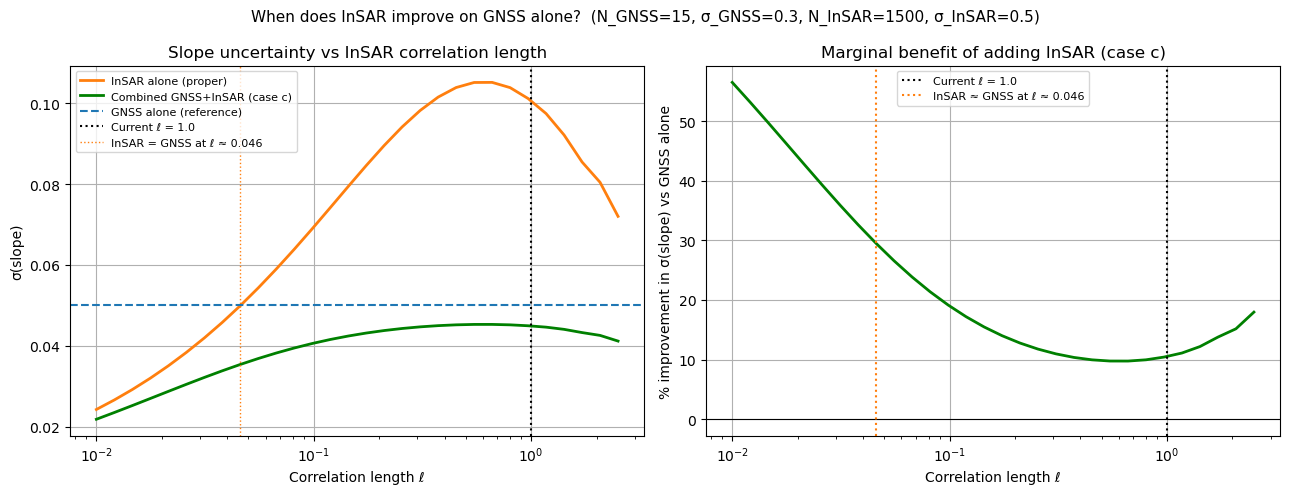

At the current ℓ = 1.0:
  σ_slope(GNSS alone)               = 0.0502
  σ_slope(InSAR proper, alone)       = 0.1011
  σ_slope(combined, case c)          = 0.0450
  Marginal benefit of InSAR:         = 10.4% improvement

InSAR matches GNSS information when ℓ ≈ 0.046


In [8]:
# ── How does the answer change with correlation length ℓ? ─────────────────────
#
# Key question: for what correlation length does InSAR become more informative
# than GNSS for slope estimation?
#
# We compute, for each ℓ:
#   - σ_slope(GNSS alone)         — constant (no ℓ dependence)
#   - σ_slope(InSAR proper alone) — increases as ℓ grows (less info)
#   - σ_slope(combined, case c)   — should always be ≤ GNSS alone

ell_values  = np.logspace(-2, 0.4, 30)    # ℓ from 0.01 to ~2.5
sigma_slope_insar   = []
sigma_slope_combined = []
sigma_slope_gnss_ref = np.sqrt(Cm_gnss[0, 0])

for ell_i in ell_values:
    # Build InSAR covariance for this ℓ
    C_i = sigma_insar**2 * np.exp(-0.5 * (dx / ell_i)**2)
    C_i += nugget * np.eye(N_insar)
    C_i_inv = np.linalg.inv(C_i)

    # InSAR alone (proper)
    _, Cm_i = wls(G_insar, d_insar, C_i_inv)
    sigma_slope_insar.append(np.sqrt(Cm_i[0, 0]))

    # Combined GNSS + InSAR (case c)
    W_c_i = block_diag(W_gnss_diag, C_i_inv)
    _, Cm_c_i = wls(G_all, d_all, W_c_i)
    sigma_slope_combined.append(np.sqrt(Cm_c_i[0, 0]))

sigma_slope_insar    = np.array(sigma_slope_insar)
sigma_slope_combined = np.array(sigma_slope_combined)

# ── Figure ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: σ_slope vs ℓ
axes[0].semilogx(ell_values, sigma_slope_insar,    color='C1',   lw=2, label='InSAR alone (proper)')
axes[0].semilogx(ell_values, sigma_slope_combined,  color='green',lw=2, label='Combined GNSS+InSAR (case c)')
axes[0].axhline(sigma_slope_gnss_ref, color='C0', ls='--', lw=1.5, label='GNSS alone (reference)')
# Mark the current ℓ
axes[0].axvline(ell, color='k', ls=':', lw=1.5, label=f'Current ℓ = {ell}')
# Mark crossover
cross_idx = np.argmin(np.abs(sigma_slope_insar - sigma_slope_gnss_ref))
axes[0].axvline(ell_values[cross_idx], color='C1', ls=':', lw=1,
                label=f'InSAR = GNSS at ℓ ≈ {ell_values[cross_idx]:.3f}')
axes[0].set_xlabel('Correlation length ℓ')
axes[0].set_ylabel('σ(slope)')
axes[0].set_title('Slope uncertainty vs InSAR correlation length')
axes[0].legend(fontsize=8)

# Right: fractional improvement from adding InSAR (case c) over GNSS alone
frac_improvement = 1 - sigma_slope_combined / sigma_slope_gnss_ref
axes[1].semilogx(ell_values, frac_improvement * 100, color='green', lw=2)
axes[1].axhline(0, color='k', lw=0.8)
axes[1].axvline(ell, color='k', ls=':', lw=1.5, label=f'Current ℓ = {ell}')
axes[1].axvline(ell_values[cross_idx], color='C1', ls=':',
                label=f'InSAR ≈ GNSS at ℓ ≈ {ell_values[cross_idx]:.3f}')
axes[1].set_xlabel('Correlation length ℓ')
axes[1].set_ylabel('% improvement in σ(slope) vs GNSS alone')
axes[1].set_title('Marginal benefit of adding InSAR (case c)')
axes[1].legend(fontsize=8)

fig.suptitle('When does InSAR improve on GNSS alone?  (N_GNSS=15, σ_GNSS=0.3, N_InSAR=1500, σ_InSAR=0.5)',
             fontsize=11)
plt.tight_layout()
plt.show()

print(f'At the current ℓ = {ell}:')
print(f'  σ_slope(GNSS alone)               = {sigma_slope_gnss_ref:.4f}')
print(f'  σ_slope(InSAR proper, alone)       = {sigma_slope_insar[np.argmin(np.abs(ell_values - ell))]:.4f}')
print(f'  σ_slope(combined, case c)          = {sigma_slope_combined[np.argmin(np.abs(ell_values - ell))]:.4f}')
print(f'  Marginal benefit of InSAR:         = {frac_improvement[np.argmin(np.abs(ell_values - ell))]*100:.1f}% improvement')
print(f'\nInSAR matches GNSS information when ℓ ≈ {ell_values[cross_idx]:.3f}')

## Summary and take-aways

| Strategy | Reported σ(slope) | Correct? | Key problem |
|----------|------------------|----------|-------------|
| GNSS alone | moderate | ✓ | — |
| InSAR naive (alone) | very small | ✗ | Treats correlated pixels as independent |
| InSAR proper (alone) | large | ✓ | Reveals true information content |
| **(a)** Combined, per-point | very small | ✗ | InSAR 100× count dominates; correlations ignored |
| **(b)** Combined, $N_k$-norm | small | ✗ | Reduces count imbalance but still ignores correlations |
| **(c)** Combined, full $C^{-1}$ | slightly smaller than GNSS | ✓ | Properly accounts for InSAR correlations |

### The central message

> **More pixels ≠ more information** when noise is spatially correlated.  With correlation length $\ell = 1$ over a profile of length $L = 5$, InSAR has only $\sim L/\ell = 5$ independent pieces of information — despite 1500 pixels.  GNSS with 15 independent stations actually carries **more** information for this configuration.

### Does $N_k$ normalization help?

$N_k$ normalization addresses the **count imbalance** but not the **correlation structure**.  It is a useful heuristic when:
- You cannot compute the full covariance (too large, unknown structure)
- You want to prevent one data type from numerically drowning out another
- Noise is roughly uncorrelated within each dataset

But it will still **overestimate the information content** of a correlated dataset, giving uncertainty bands that are too narrow.  The reported improvement over GNSS alone (case b) is optimistic relative to the correct answer (case c).

### When is InSAR actually worth including?

The varying-$\ell$ analysis shows that InSAR becomes more informative than GNSS only when $\ell$ is small enough that the pixels are effectively independent.  The crossover point depends on $N_\text{GNSS}$, $\sigma_\text{GNSS}$, $\sigma_\text{InSAR}$, and $L$.  For the parameters here, $\ell \lesssim 0.05$ is needed for InSAR to outperform GNSS on slope estimation.  At $\ell = 1.0$, InSAR adds only a few percent improvement in slope precision.

**The practical lesson**: before combining datasets, estimate the InSAR correlation length and check whether the proper covariance treatment actually improves the inversion.  If $N_\text{eff} \ll N_\text{GNSS}$, the large InSAR dataset may add little — but reporting it as if it does is misleading.

## Exercises

1. **Reduce $\ell$** to 0.05 and re-run cases (a)–(c).  Do the three strategies converge?  Why?

2. **Increase $\sigma_\text{InSAR}$** to 2.0.  At what $\sigma_\text{InSAR}$ does InSAR become useless regardless of $\ell$?

3. **Sparse GNSS**: Reduce $N_\text{GNSS}$ to 3 stations covering only part of the x-range.  Does InSAR now add more value?  Explain.

4. **Misspecified $\ell$**: Suppose you use case (c) but estimate the wrong correlation length.  Try using $\ell = 0.1$ in the weight matrix when the true $\ell = 1.0$.  Does the point estimate change?  Does the uncertainty?

5. **Systematic bias in InSAR**: Add a constant offset of +0.5 to `d_insar` (simulating orbital ramp error).  Which strategy (a, b, or c) is most robust to this bias?  Why?